# Data Analytics Programming Project
## Phase 1: DATA PREPARATION AND CLEANING
### Team Members:
* LUBNA AL HAANI BINTI RADZUAN (A23CS0107)
* NAWWARAH AUNI BINTI NAZRUDIN (A23CS0143)
* NURUL IKA SYAFINY BINTI AZHAR (A23CS0164)
* NURAISYAH BINTI MOHD ZIKRE (A23CS0160)
* NAJMA SHAKIRAH BINTI SHAHRULZAMAN (A23CS0140)

### 1.0 Research Question
The primary research question for this phase is:

"How do different vehicle characteristics influence CO2 emissions, and how can we match 2025 car registration data with known emission factors to uncover meaningful insights?"

By analyzing vehicle fuel consumption and emission data, we aim to:

- Match 2025 registered car models with their 2014 fuel consumption and emission data.

- Identify vehicle categories with high CO2 emissions.

- Lay the foundation for visual and predictive analytics in the next phase.

### 2.0 Data Cleaning
In this step, we loaded the dataset and clean both dataset, includes standardize column name and remove duplicates. This step ensures that our data is reliable and suitable for deeper analytical operations.

We first import **pandas** library to handle and analyze the data and **.read_csv()** is used to load both datasets into the script.

In [244]:
import pandas as pd

# Load datasets
fuel_df = pd.read_csv("FuelConsumption.csv")
cars_df = pd.read_csv("cars_2025.csv")

Then, we use the **.columns** function to compare columns name in each dataframe. After we observed, column name "MAKE" in Fuel Consumption dataset does not match with the column named "maker" in Cars_2025 dataset. Additionally, we notice a difference in letter casing across both datasets (e.g., "MAKE" vs "maker").

Then, we use the **.isnull()** along with the **.sum()** functions to check for missing (null) values in each column of both DataFrames. **.isnull()** return boolean value where True is indicating whether the dataset contains null value and both datasets does not have null value since all return value is 0 which is False.

In [246]:
# Print all columns name in both dataset
print("Fuel Dataset Columns:", fuel_df.columns)
print("Cars Dataset Columns:", cars_df.columns)

# Check for missing values
print(fuel_df.isnull().sum())
print(cars_df.isnull().sum())

Fuel Dataset Columns: Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')
Cars Dataset Columns: Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')
MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64
date_reg    0
type        0
maker       0
model       0
colour      0
fuel        0
state       0
dtype: int64


The **.columns.str.strip().str.lower().str.replace(" ", "_")** code contains a few diffent functions. First one is **.str.strip()** is to remove any whitespace from column names. Next, **.str.lower()** is used to change all column name to lowercase. Last but not least, **.str.replace()** is used to replace any spaces with "_" character to make all the column names is consistent.

Then, **.rename()** is used to change the "make" column name in fuel_consumption to "maker" to match with the other dataset.

**.dropna()** used to drop any row in each dataset with null value in maker and model columns.

Lastly, in this section, **.columns()** is used to check whether all column names needed for analyzation is matched and ready to use.

In [248]:
# Standardize column names
fuel_df.columns = fuel_df.columns.str.strip().str.lower().str.replace(" ", "_")
cars_df.columns = cars_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename column 'make' in FuelConsumption to 'maker' to standardize with cars_2025
fuel_df.rename(columns={'make': 'maker'}, inplace=True)

# Drop rows with missing model or make
fuel_df.dropna(subset=['maker', 'model'], inplace=True)
cars_df.dropna(subset=['maker', 'model'], inplace=True)

print("Fuel Dataset Columns:", fuel_df.columns)
print("Cars Dataset Columns:", cars_df.columns)

Fuel Dataset Columns: Index(['modelyear', 'maker', 'model', 'vehicleclass', 'enginesize',
       'cylinders', 'transmission', 'fueltype', 'fuelconsumption_city',
       'fuelconsumption_hwy', 'fuelconsumption_comb',
       'fuelconsumption_comb_mpg', 'co2emissions'],
      dtype='object')
Cars Dataset Columns: Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')


Same as the column names before but with loop, the data in each datasets are also cleaned by using **.str.lower()** function to change all data into lowercase and **.str.strip()** function to remove any unnecessary whitespaces.

**.head()** is used after standardize to check whether there are error with the replacement or the modification.

In [250]:
# Standardize data
for col in fuel_df.select_dtypes(include='object').columns:
    fuel_df[col] = fuel_df[col].str.lower().str.strip()

for col in cars_df.select_dtypes(include='object').columns:
    cars_df[col] = cars_df[col].str.lower().str.strip()

print("Fuel Consumption Data:")
display(fuel_df.head())

print("\nCars 2025 Data:")
display(cars_df.head())

Fuel Consumption Data:


,modelyear,maker,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2014,acura,ilx,compact,2.0,4,as5,z,9.9,6.7,8.5,33,196
1,2014,acura,ilx,compact,2.4,4,m6,z,11.2,7.7,9.6,29,221
2,2014,acura,ilx hybrid,compact,1.5,4,av7,z,6.0,5.8,5.9,48,136
3,2014,acura,mdx 4wd,suv - small,3.5,6,as6,z,12.7,9.1,11.1,25,255
4,2014,acura,rdx awd,suv - small,3.5,6,as6,z,12.1,8.7,10.6,27,244



Cars 2025 Data:


,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,byd,seal,white,electric,rakan niaga
1,2025-01-01,window_van,cam,placer-x,yellow,greendiesel,johor
2,2025-01-01,jip,chery,jaecoo j7,green,petrol,rakan niaga
3,2025-01-01,jip,chery,jaecoo j7,silver,petrol,rakan niaga
4,2025-01-01,jip,chery,tiggo,grey,petrol,rakan niaga


Then, **.duplicated()** along with the **.sum()** function are used to check duplicates data and count the number of duplicates in each datasets. After run the code, we found 0 duplicate in fuel_consumption dataset while cars_2025 have as much as 215141 duplicates.

Hence, **.shape[]** function is used to show the total rows and **.drop_duplicated()** and **.shape[]** function used together to get the total of unique rows left if all the duplicates is removed. Then, **.drop_duplicates()** is used to drop all the duplicated rows and print "Duplicated rows are dropped" if dropping is successful.

In [252]:
# Check how many duplicate rows there are
print("Fuel duplicates:", fuel_df.duplicated().sum())
print("Cars duplicates:", cars_df.duplicated().sum())

# Show duplicate rows
# Check how many total rows and unique rows
print()
print("Duplicates in Cars_2025:")
print("Total rows:", cars_df.shape[0])
print("Unique rows:", cars_df.drop_duplicates().shape[0])

# Drop exact duplicate rows
cars_df.drop_duplicates(inplace=True)

print("Duplicated rows are dropped")

Fuel duplicates: 0
Cars duplicates: 215141

Duplicates in Cars_2025:
Total rows: 263578
Unique rows: 48437
Duplicated rows are dropped


Lastly for data cleaning, after cleaning is done, both datasets is exported into .csv using the **.to_csv()** function.

In [254]:
# Save cleaned data into new .csv files
cars_df.to_csv("cars_2025_cleaned.csv", index=False)
fuel_df.to_csv("fuel_consumption_cleaned.csv", index=False)

### 3.0 Data Wrangling & Preparation
In the data wrangling process, the first step was to merge two datasets, cars_df and fuel_df, using the common columns 'maker' and 'model' with a right join method. This approach was chosen to ensure that all entries from the fuel_df were retained, even if some corresponding values from cars_df were missing. After merging, the structure and sample records of the resulting dataset were reviewed to confirm the success of the operation.

In [256]:
# Merge datasets on 'maker' and 'model'
merged_df = pd.merge(cars_df, fuel_df, on=['maker', 'model'], how='right')

print("Merged Dataset:")
display(merged_df.head())

print("\nMerged shape:", merged_df.shape)

Merged Dataset:


,date_reg,type,maker,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,NaN,NaN,acura,ilx,NaN,NaN,NaN,2014,compact,2.0,4,as5,z,9.9,6.7,8.5,33,196
1,NaN,NaN,acura,ilx,NaN,NaN,NaN,2014,compact,2.4,4,m6,z,11.2,7.7,9.6,29,221
2,NaN,NaN,acura,ilx hybrid,NaN,NaN,NaN,2014,compact,1.5,4,av7,z,6.0,5.8,5.9,48,136
3,NaN,NaN,acura,mdx 4wd,NaN,NaN,NaN,2014,suv - small,3.5,6,as6,z,12.7,9.1,11.1,25,255
4,NaN,NaN,acura,rdx awd,NaN,NaN,NaN,2014,suv - small,3.5,6,as6,z,12.1,8.7,10.6,27,244



Merged shape: (10188, 18)


Following the merge, the dataset was examined for missing values. Rows containing null values were removed to maintain data consistency and reliability. Additionally, the dataset was checked for duplicate entries to prevent redundancy, and the total number of duplicate rows was displayed. Once the dataset was cleaned and verified, it was saved as a CSV file named merged_cleaned_data.csv, making it ready for further analysis or modeling tasks.

In [257]:
# Check for missing values
print("Missing values in merged dataset:")
print(merged_df.isnull().sum())

# Drop row with missing values
merged_df.dropna(inplace=True)

# Check how many duplicate rows there are
print("\nDuplicate rows in merged dataset:", merged_df.duplicated().sum())

print("\nFinal shape after cleaning:", merged_df.shape)

print("\nMerged Dataset:")
display(merged_df.head())

Missing values in merged dataset:
date_reg                    976
type                        976
maker                         0
model                         0
colour                      976
fuel                        976
state                       976
modelyear                     0
vehicleclass                  0
enginesize                    0
cylinders                     0
transmission                  0
fueltype                      0
fuelconsumption_city          0
fuelconsumption_hwy           0
fuelconsumption_comb          0
fuelconsumption_comb_mpg      0
co2emissions                  0
dtype: int64

Duplicate rows in merged dataset: 0

Final shape after cleaning: (9212, 18)

Merged Dataset:


,date_reg,type,maker,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
18,2025-04-22,motokar,aston martin,vanquish,green,petrol,w.p. kuala lumpur,2014,minicompact,5.9,12,a6,z,18.0,12.6,15.6,18,359
19,2025-03-06,motokar,audi,a4,silver,petrol,johor,2014,compact,2.0,4,av8,z,9.9,7.4,8.8,32,202
20,2025-03-06,motokar,audi,a4,black,petrol,pahang,2014,compact,2.0,4,av8,z,9.9,7.4,8.8,32,202
31,2025-01-31,motokar,audi,a8,grey,petrol,w.p. kuala lumpur,2014,mid-size,3.0,6,as8,z,13.1,8.8,11.2,25,258
32,2025-04-25,motokar,audi,a8,grey,petrol,w.p. kuala lumpur,2014,mid-size,3.0,6,as8,z,13.1,8.8,11.2,25,258


In [258]:
# Save the final cleaned and merged dataset
merged_df.to_csv("merged_cleaned_data.csv", index=False)
print("Merged and cleaned dataset saved to 'merged_cleaned_data.csv'")

Merged and cleaned dataset saved to 'merged_cleaned_data.csv'


Next, we prepare the dataset to fullfill the machine learning needs. Below is the steps for data preparation. We will import everthing we need first such as pandas, LabelEncoder and StandardScaler.

In [260]:
!pip install scikit-learn

In [261]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

First of all, we load the merged dataset from before.

In [263]:
# Load cleaned merged dataset
merged_df = pd.read_csv("merged_cleaned_data.csv")
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

Then, we put the datasets into bins. The bins divide the co2emissions values into three intervals:

Low: 0 to 150

Medium: 150 to 200

High: above 200

The **pd.cut()** function is used to map each vehicle's co2emissions value to a corresponding emission class based on the defined bins and labels. A new column called 'emission_class' is added to the DataFrame merged_df, containing the label ('low', 'medium', or 'high') for each vehicle. Then, we display the updated DataFrame so we can verify that the emission_class column has been correctly added and labeled.

In [265]:
# Step 1: Create emission class (target labels)
bins = [0, 150, 200, float('inf')]
labels = ['low', 'medium', 'high']
merged_df['emission_class'] = pd.cut(merged_df['co2emissions'], bins=bins, labels=labels)
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku


This step is essential for supervised machine learning tasks where CO₂ emissions need to be predicted or analyzed in categories rather than as continuous numerical values. It converts a regression problem into a classification problem.


The next step is dropping unncecessary collumn. We will create a new DataFrame X, which contains the independent variables (features) used to predict the emission class. It removes the following columns from the dataset:

'model': This is likely a very specific identifier for each vehicle (e.g., "Toyota Camry LE"), which can lead to overfitting and doesn't generalize well for prediction.

'co2emissions': This numeric column was used to create the emission_class label. Keeping it would be data leakage, as it directly contains the information you're trying to predict.

'emission_class': This is the target label, so it is excluded from the features.

The we created a y that stores the dependent variable (target), which is the categorical class label ('low', 'medium', 'high') created in Step 1. This will be used during model training to learn the relationship between the features in X and the emission class. Then, we print both X and y to shows the feature set to verify that only the relevant columns remain for training the model.

In [267]:
# Step 2: Drop columns not needed
# - Drop `model` (too specific)
# - Drop `co2_emissions_g/km` (we've created categorical label)
# - Keep `maker`
X = merged_df.drop(columns=['model', 'co2emissions', 'emission_class'])
y = merged_df['emission_class']
print(X)

        date_reg     type         maker  colour           fuel  \
0     2025-04-22  motokar  aston martin   green         petrol   
1     2025-03-06  motokar          audi  silver         petrol   
2     2025-03-06  motokar          audi   black         petrol   
3     2025-01-31  motokar          audi    grey         petrol   
4     2025-04-25  motokar          audi    grey         petrol   
...          ...      ...           ...     ...            ...   
9207  2025-04-30      jip         volvo   white  hybrid_petrol   
9208  2025-04-30      jip         volvo  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo   black  hybrid_petrol   
9210  2025-04-30      jip         volvo   white  hybrid_petrol   
9211  2025-04-30      jip         volvo    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. kuala lumpur       2014  minicompact         5.9         12   
1                 johor       2014      compact         2.0

In [268]:
print(y)

0       high
1       high
2       high
3       high
4       high
        ... 
9207    high
9208    high
9209    high
9210    high
9211    high
Name: emission_class, Length: 9212, dtype: category
Categories (3, object): ['low' < 'medium' < 'high']


This preprocessing step ensures that the dataset only contains useful and generalizable information for training the model. Removing irrelevant or problematic columns improves model performance and reduces the risk of overfitting or data leakage.


Then, we encode the 'maker' collumn. This step transforms the categorical feature 'maker' (e.g., Toyota, Honda, Ford) into numerical values so it can be used by machine learning models, which generally require numerical input. Firstly, we creates an instance of LabelEncoder from sklearn.preprocessing. LabelEncoder converts text labels into integer values, assigning a unique number to each category. This line applies the label encoding to the 'maker' column in the feature set X. For example:

'Toyota' might be encoded as 3

'Honda' as 1

'Ford' as 0, etc.

The encoder assigns integer labels alphabetically by default. Then, we print the merged_df.

In [270]:
# Step 3: Encode 'maker' with LabelEncoder
le_maker = LabelEncoder()
X['maker'] = le_maker.fit_transform(X['maker'])
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

This step is important since machine learning algorithms cannot process string labels directly. By encoding the 'maker' column into numbers, this step makes the data machine-readable and ready for model training.

The last step is we encode the remaining categorical collumns. This step ensures that all remaining categorical (text) columns in the feature set X are converted into numerical values using label encoding. First, we selects all columns in X that have the data type 'object', which usually indicates string values. Examples might include:

'transmission' (e.g., 'Automatic', 'Manual')

'fuel_type' (e.g., 'Petrol', 'Diesel', 'Electric')

For each of these text-based columns, LabelEncoder is applied to convert the string categories into unique integers. For example:

'Automatic' → 0, 'Manual' → 1

'Petrol' → 2, 'Diesel' → 0, 'Electric' → 1 (alphabetical order)

Then, we print the merged_df

In [272]:
# Step 4: Encode any other categorical columns (e.g., transmission, fuel_type)
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

This step ensures all categorical features are numeric, which is a requirement for most machine learning models. It generalizes the encoding step from Step 3 (which was only for 'maker') to apply automatically to any remaining object-type columns.

### 4.0 Data Aggregation and Group Operations
After cleaning and merging, we performed comprehensive data aggregation to understand vehicle registration patterns and fuel type distributions across different dimensions.

We first load the cleaned dataset using **pd.read_csv()** and prepare it for analysis by converting the **'date_reg'** column to datetime format using **pd.to_datetime()**. 

We then create a monthly period column by extracting the month from the datetime using **dt.to_period('M')**, which groups dates into monthly buckets for trend analysis. Next, we identify the top 5 states by registration count using **value_counts().head(5)** on the **'state'** column, which ranks all states by their total registration numbers and selects the five highest.

After identifying the top states, we filter the dataset to include only records from these top 5 states using **df[df['state'].isin(top_states_list)]**, which creates a focused subset for detailed analysis. We then perform a groupby operation on both 'reg_month' and 'state' columns, using .size() to count registrations for each month-state combination. 

For visualization, we create a line plot that displays monthly registration trends for each of the top 5 states separately. The plot uses a loop to iterate through each state and plot its registration counts over time, with different colors and labels for each state line. This visualization shows temporal patterns and allows comparison of registration trends between the top 5 states.

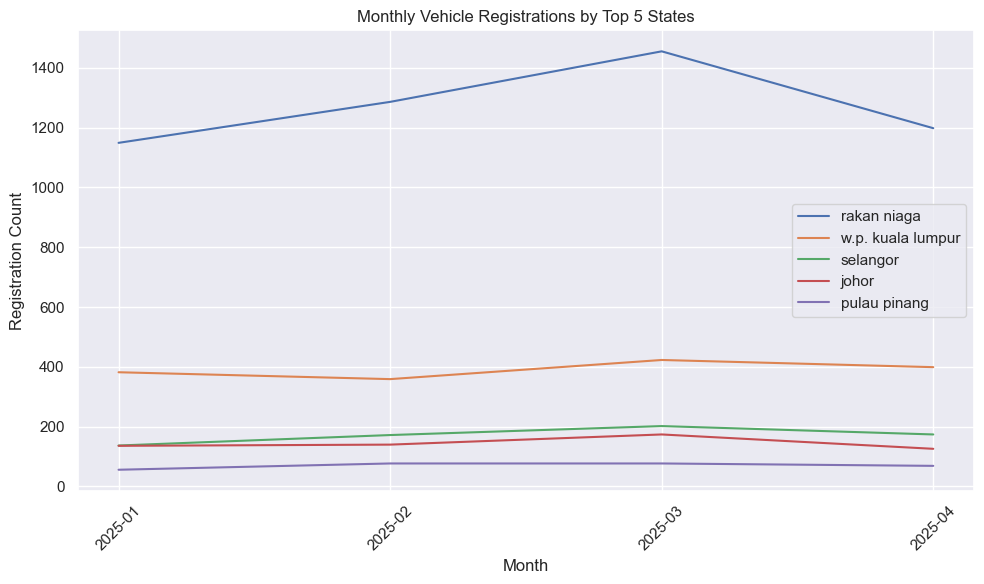

In [275]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load and Prepare the Dataset ===
df = pd.read_csv('merged_cleaned_data.csv')
df['date_reg'] = pd.to_datetime(df['date_reg'], errors='coerce')
df['reg_month'] = df['date_reg'].dt.to_period('M')

# === Get Top 5 States by Registration Count ===
top5_states = (
    df['state']
    .value_counts()
    .head(5)
)
top_states_list = top5_states.index.tolist()

# === Filter Data for Top 5 States Only ===
df_top_states = df[df['state'].isin(top_states_list)]

# === Monthly Registration Trend for Top 5 States ===
df_top_states.loc[:, 'reg_month'] = df_top_states['date_reg'].dt.to_period('M')

monthly_by_state = (
    df_top_states.groupby(['reg_month', 'state'])
    .size()
    .reset_index(name='registration_count')
    .sort_values('reg_month')
)

# === Plot: Line Plot for Monthly Registrations per Top State ===
plt.figure(figsize=(10, 6))
for state in top_states_list:
    data = monthly_by_state[monthly_by_state['state'] == state]
    plt.plot(data['reg_month'].astype(str), data['registration_count'], label=state)

plt.xlabel('Month')
plt.ylabel('Registration Count')
plt.title('Monthly Vehicle Registrations by Top 5 States')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In this analysis, we create a cross-tabulation table using **pd.crosstab(df['vehicleclass'], df['fuel'])** to see how many vehicles of each class use each fuel type. 

Then we normalize this data to percentages using **.div(vehicle_fuel_crosstab.sum(axis=1), axis=0).round(2)** - this divides each row by its total and rounds to 2 decimal places, so we can see what proportion of each vehicle class uses each fuel type.
    
For visualization, we use **vehicle_fuel_pct.plot(kind='bar', stacked=True)** to create a stacked bar chart where each bar represents a vehicle class and the colored segments show the fuel type proportions. We set the figure size to (10, 6) and use the 'tab20' colormap for distinct colors.

We add labels with plt.title(), plt.xlabel(), and plt.ylabel() to make the chart clear. The legend is positioned outside the plot area using bbox_to_anchor=(1.05, 1), loc='upper left' so it doesn't overlap with the data. Finally, plt.tight_layout() ensures everything fits properly and plt.show() displays the chart. This gives us a clear view of fuel preferences across different vehicle classes.

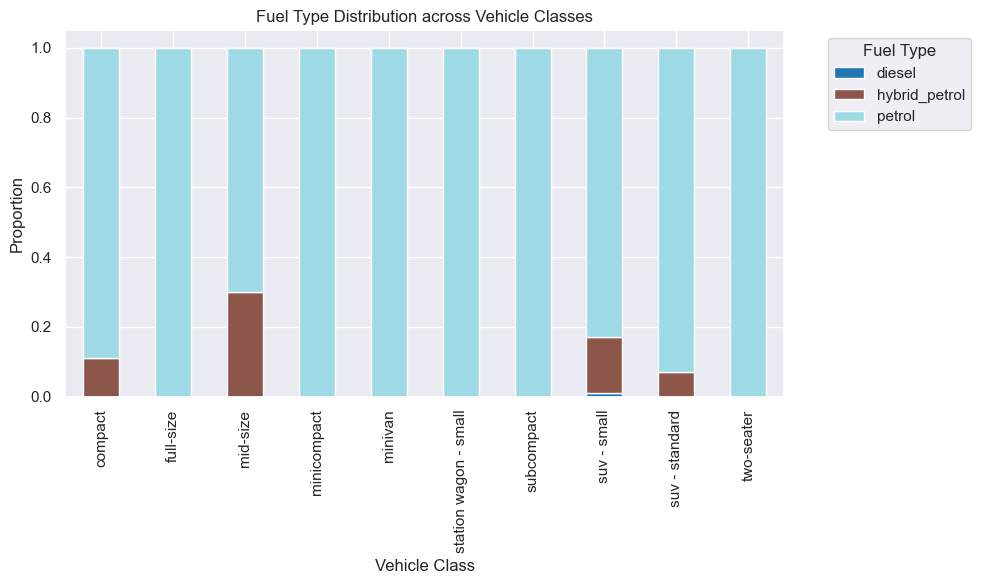

In [277]:
# === Cross-tab of Vehicle Class and Fuel Type ===
vehicle_fuel_crosstab = pd.crosstab(df['vehicleclass'], df['fuel'])

# === Normalize to Percentage for Better Insight ===
vehicle_fuel_pct = vehicle_fuel_crosstab.div(vehicle_fuel_crosstab.sum(axis=1), axis=0).round(2)

# === Plot: Stacked Bar Chart ===
vehicle_fuel_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Fuel Type Distribution across Vehicle Classes')
plt.xlabel('Vehicle Class')
plt.ylabel('Proportion')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.0 Conclusion for Phase 1

Phase 1 successfully prepared and processed the datasets through systematic data cleaning and integration. Key accomplishments include:  

1. **Data Cleaning & Standardization** – Removed 215,141 duplicate entries, standardized column names and values, and handled missing data to ensure consistency.  
2. **Data Wrangling & Merging** – Effectively combined 2025 vehicle registration records with 2014 fuel consumption and emission datasets.  
3. **Data Grouping & Aggregation** – Performed group operations to analyze registration trends by state and fuel type distributions across vehicle classes.  
4. **Initial Insights** – Established baseline metrics for emission patterns and vehicle characteristics.  

This phase has created a reliable, analysis-ready dataset of 9,212 records. The cleaned and structured data provides a solid foundation for Phase 2, where we will conduct deeper visual analytics and predictive modeling to examine CO₂ emission patterns and their key influencing factors. The dataset is now optimally prepared for advanced analysis to support data-driven insights and decision-making.

# PHASE 2 : DATA ANALYTIC AND VISUALIZATION
With our data now clean and prepared from Phase 1, Phase 2 marks our transition into the core of understanding and communicating its insights. Our primary goal here is to delve into the cleaned dataset, using both analytical techniques and visual representation to uncover meaningful patterns and relationships. This phase will allow us to effectively interpret how various vehicle characteristics influence CO2 emissions, ultimately transforming our processed data into clear, understandable, and actionable knowledge.

### 1.0 Summary Analytics
Summary analytics involves using descriptive statistics to summarize and describe the main features of a dataset. It helps to quickly understand the basic characteristics of the data, such as averages, totals, frequencies, and the relationships between variables, without making complex predictions or inferences. Essentially, it's about getting a clear overview of "what happened" in the data.

In [280]:
# Summary 1: Unique counts
unique_summary = pd.DataFrame({
    'Metric': ['Unique car makers', 'Unique car models'],
    'Count': [merged_df['maker'].nunique(), merged_df['model'].nunique()]
})
print("Number of Unique Car Makers and Models")
display(unique_summary)

# Summary 2: Top 5 car makers by frequency
top_makers = merged_df['maker'].value_counts().head().reset_index()
top_makers.columns = ['Car Maker', 'Number of Vehicles']
print("Top 5 Car Makers by Number of Vehicles")
display(top_makers)

# Summary 3: Average CO2 emissions by car maker (Top 5)
avg_emissions = (
    merged_df.groupby('maker')['co2emissions']
    .mean()
    .sort_values(ascending=False)
    .head()
    .reset_index()
)
avg_emissions.columns = ['Car Maker', 'Average CO2 Emissions (g/km)']
print("Average CO2 Emissions by Car Maker (Top 5)")
display(avg_emissions)

# Summary 4: Vehicle classes with highest average emissions
if 'vehicleclass' in merged_df.columns:
    avg_by_class = (
        merged_df.groupby('vehicleclass')['co2emissions']
        .mean()
        .sort_values(ascending=False)
        .head()
        .reset_index()
    )
    avg_by_class.columns = ['Vehicle Class', 'Average CO2 Emissions (g/km)']
    print("Vehicle Classes with Highest Average CO2 Emissions")
    display(avg_by_class)

# Summary 5: Correlation between fuel consumption and CO2 emissions
if 'fuelconsumption_comb' in merged_df.columns:
    correlation = merged_df['fuelconsumption_comb'].corr(merged_df['co2emissions'])
    correlation_df = pd.DataFrame({
        'Metric': ['Correlation between fuel consumption and CO2 emissions'],
        'Value': [(correlation, 3)]
    })
    print("Correlation Analysis")
    display(correlation_df)


Number of Unique Car Makers and Models


,Metric,Count
0,Unique car makers,21
1,Unique car models,49


Top 5 Car Makers by Number of Vehicles


,Car Maker,Number of Vehicles
0,honda,4326
1,mazda,1766
2,toyota,1391
3,porsche,699
4,volkswagen,434


Average CO2 Emissions by Car Maker (Top 5)


,Car Maker,Average CO2 Emissions (g/km)
0,aston martin,359.000000
1,bentley,348.600000
2,maserati,347.000000
3,nissan,297.000000
4,porsche,281.244635


Vehicle Classes with Highest Average CO2 Emissions


,Vehicle Class,Average CO2 Emissions (g/km)
0,suv - standard,294.241779
1,subcompact,282.318182
2,full-size,251.000000
3,minivan,244.186047
4,two-seater,234.000000


Correlation Analysis


,Metric,Value
0,Correlation between fuel consumption and CO2 e...,"(0.9999815061641547, 3)"


This code performs various summary analytics to give us a quick overview of the merged dataset, focusing on car manufacturers, models, and CO2 emissions.

Here's a breakdown of each section:

1.  **Summary 1: Unique Counts**
    This part calculates and displays the total number of *unique* car makers and unique car models present in the `merged_df` dataset. It gives us a       sense of the diversity and scale of car manufacturers and models represented in the data.

2.  **Summary 2: Top 5 Car Makers by Frequency**
    It counts how many vehicles belong to each `maker` (car manufacturer) and then shows the top 5 makers with the highest number of vehicles in the        dataset. This helps identify the most common or prominent car brands within the data, indicating which manufacturers have the largest presence.

3.  **Summary 3: Average CO2 Emissions by Car Maker (Top 5)**
    This code groups the data by `maker` and calculates the average `co2emissions` for each car maker. It then sorts these averages from highest to         lowest and displays the top 5 car makers with the highest average CO2 emissions. Its function is to highlights which car manufacturers, on average,     produce the most CO2 per vehicle in your dataset, pointing to brands that might be less environmentally friendly.

4.  **Summary 4: Vehicle Classes with Highest Average Emissions**
    Similar to Summary 3, but this section groups the data by `vehicleclass` (e.g., SUV, Sedan, Compact) and finds the top vehicle classes that have        the highest average `co2emissions`. The `if 'vehicleclass' in merged_df.columns:` ensures this code only runs if the 'vehicleclass' column actually     exists in the DataFrame. This helps identify which types of vehicles, regardless of maker, tend to have higher CO2 emissions, providing insights        into emission trends based on car category.

5.  **Summary 5: Correlation between fuel consumption and CO2 emissions**
    This calculates the Pearson correlation coefficient between the `fuelconsumption_comb` (combined fuel consumption) and `co2emissions` columns. The      `if 'fuelconsumption_comb' in merged_df.columns:` ensures this runs only if the column exists. The result is a single value indicating the strength     and direction of the linear relationship between these two variables. A value close to 1 indicates a strong positive relationship (as one               increases, the other tends to increase), while a value close to -1 indicates a strong negative relationship. It quantitatively tells us how closely     combined fuel consumption and CO2 emissions are linked. A strong positive correlation is expected, as burning more fuel generally leads to higher       CO2 output. This confirms a fundamental relationship in the data between fuel consumption and CO2 emissions.

### 2.0 Appropiate Machine Learning
To gain a deeper understanding of vehicle emission patterns, we employ K-Means clustering, an unsupervised machine learning technique. This method allows us to automatically group similar car models together based on their CO2 emissions and fuel consumption. By identifying distinct clusters, we can categorize vehicles into meaningful emission groups, providing a clearer picture of performance across different car makers and models.

In [282]:
# Using summary 3: Group by car maker to clustering car maker according to their carbon emissions
avg_emissions_clustering = (
    merged_df.groupby(['maker', 'model'])[['co2emissions', 'fuelconsumption_comb']]
    .mean()
    .reset_index()
)
display(avg_emissions_clustering.head())

# Scale and apply KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = avg_emissions_clustering[['co2emissions', 'fuelconsumption_comb']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=0)
avg_emissions_clustering['cluster'] = kmeans.fit_predict(X_scaled)

#sort clustering average value to name cluster label
cluster_means = avg_emissions_clustering.groupby('cluster')['co2emissions'].mean().sort_values()

# Get sorted cluster emission levels index and turn into list
cluster_order = cluster_means.sort_values().index.tolist()

# Create a label map
label_map = {
    cluster_order[0]: 'Low Emission Group',
    cluster_order[1]: 'Medium Emission Group',
    cluster_order[2]: 'High Emission Group'
}

# Apply label map clustering result
avg_emissions_clustering['cluster_label'] = avg_emissions_clustering['cluster'].map(label_map)

#cluster summary
cluster_summary = avg_emissions_clustering.groupby(['cluster', 'cluster_label'])[['co2emissions', 'fuelconsumption_comb']].mean().reset_index()
cluster_summary.columns = ['Cluster', 'Cluster Label', 'Average CO₂ Emissions', 'Average Fuel Consumption']
display(cluster_summary)

display(avg_emissions_clustering)


,maker,model,co2emissions,fuelconsumption_comb
0,aston martin,vanquish,359.0,15.60
1,audi,a4,202.0,8.80
2,audi,a8,259.0,11.25
3,audi,q5,248.5,10.80
4,audi,q7,304.0,13.20


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Cluster,Cluster Label,Average CO₂ Emissions,Average Fuel Consumption
0,0,Low Emission Group,201.127193,8.744298
1,1,High Emission Group,361.333333,15.712500
2,2,Medium Emission Group,268.220833,11.653750


,maker,model,co2emissions,fuelconsumption_comb,cluster,cluster_label
0,aston martin,vanquish,359.000000,15.600000,1,High Emission Group
1,audi,a4,202.000000,8.800000,0,Low Emission Group
2,audi,a8,259.000000,11.250000,2,Medium Emission Group
3,audi,q5,248.500000,10.800000,2,Medium Emission Group
4,audi,q7,304.000000,13.200000,2,Medium Emission Group
5,audi,r8,376.500000,16.375000,1,High Emission Group
6,audi,rs7,290.000000,12.600000,2,Medium Emission Group
7,audi,s8,297.000000,12.900000,2,Medium Emission Group
8,audi,sq5,292.000000,12.700000,2,Medium Emission Group
9,bentley,continental gt,326.500000,14.200000,1,High Emission Group


This code performs K-Means clustering to group car makers and models based on their average CO2 emissions and fuel consumption. The goal is to categorize them into different "emission groups" (e.g., Low, Medium, High).

**1. Initial Data Preparation for Clustering**
   Before clustering, we need one data point per "entity" we want to cluster. Here, the entities are unique combinations of maker and model. This code     groups the original merged_df by maker and model and then calculates the average co2emissions and fuelconsumption_comb for each maker-model pair.
   The .reset_index() turns the grouped result back into a flat DataFrame. This creates a dataset where each row represents a distinct car model (from     a specific maker), with its average CO2 emissions and fuel consumption. This aggregated data is what the clustering algorithm will use.

**2. Scaling the Data**
   K-Means clustering algorithms are sensitive to the scale of our features. If co2emissions values are much larger than fuelconsumption_comb values,      the clustering might be unfairly biased towards co2emissions. StandardScaler transforms the data so that each feature (co2emissions and                 fuelconsumption_comb) has a mean of 0 and a standard deviation of 1. Scaling is important because it ensures that both features contribute equally      to the distance calculations used by K-Means, preventing one feature from dominating the clustering process just because of its larger numerical        range.

**3. Applying K-Means Clustering**
    kmeans = KMeans(n_clusters=3, random_state=0):
    
    KMeans: This is the clustering algorithm.
    
    n_clusters=3: This tells the algorithm to try and find 3 distinct groups (clusters) within the data. The choice of 3 here implies we want to            categorize into "Low," "Medium," and "High" emission groups.
    
    random_state=0: This sets a seed for the random number generator. It's crucial for reproducibility; if we run the code multiple times with the same     random_state, you'll get the exact same clustering results.
    
    avg_emissions_clustering['cluster'] = kmeans.fit_predict(X_scaled):

    fit_predict(X_scaled): This method first "fits" the K-Means model to our scaled data (X_scaled), meaning it learns the optimal cluster centers.         Then, it "predicts" which cluster each data point (each car maker-model pair) belongs to.

The result (a number representing the cluster ID, typically 0, 1, 2 for 3 clusters) is then added as a new column named 'cluster' to our                avg_emissions_clustering DataFrame.

**4. Assigning Meaningful Cluster Labels**
    The cluster IDs (0, 1, 2) are arbitrary numbers assigned by K-Means. This part of the code aims to give them meaningful labels like "Low Emission       Group," "Medium Emission Group," and "High Emission Group."
    
    cluster_means: It calculates the average CO2 emissions for each cluster.
    
    cluster_order: It then sorts these average CO2 emissions from lowest to highest and gets the corresponding cluster IDs. This ensures that the           cluster with the lowest average CO2 emissions is identified as the "low" group, the middle one as "medium," and the highest as "high."
    
    label_map: This creates a dictionary that maps the arbitrary cluster IDs (e.g., 0, 1, 2) to their descriptive labels (e.g., 'Low Emission Group').
    
    avg_emissions_clustering['cluster_label'] = ... .map(label_map): This applies the label_map to the 'cluster' column, creating a new human-readable      'cluster_label' column in your DataFrame.
    
   
It is useful for making the clustering results much easier to understand and interpret. Instead of saying "Cluster 0," we can say "Low Emission         Group."

**5. Summarizing the Clusters**
   This groups the data by the newly assigned cluster and cluster_label and calculates the average co2emissions and fuelconsumption_comb for each of       the named clusters. This table provides a concise summary of the characteristics of each identified cluster, allowing us to quickly see the average     CO2 emissions and fuel consumption for the "Low," "Medium," and "High" emission groups.

**6. Displaying Clustered Data**
   This simply displays the entire avg_emissions_clustering DataFrame, which now includes the original maker, model, co2emissions,                         fuelconsumption_comb, along with the new 'cluster' ID and 'cluster_label' for each car model. This allows us to see which specific car models fall      into which emission group.

### 3.0 Data Visualisation
In this part, we will visualize the cleaned dataset to uncover patterns and relationships related to CO₂ emissions. The goal is to support our data analysis with visual insights by using Seaborn and Matplotlib.

#### 1. Correlation Heatmap — *“Which features matter most?”*

The correlation heatmap below visualizes the relationships between all numerical variables in the dataset. To create this visualization, the dataset is first filtered to include only numeric columns using the select_dtypes() method. Then, the .corr() function is applied to calculate the Pearson correlation coefficient for each pair of numerical features, which measures how strongly two variables are linearly related. The result is a symmetric matrix of correlation values ranging from -1 to 1. This matrix is then passed to the sns.heatmap() function from the Seaborn library, which uses a diverging color palette (coolwarm) to distinguish between positive and negative correlations. Each cell in the heatmap is annotated with the exact correlation value using annot=True, and the layout is adjusted for readability using tight_layout().

From the heatmap shown below, it shows the correlation between all numerical variables. The heatmap helps in identify which feature have strong relationship that related to CO₂ emissions where it also will help us to know which variables are most important to analyze further.


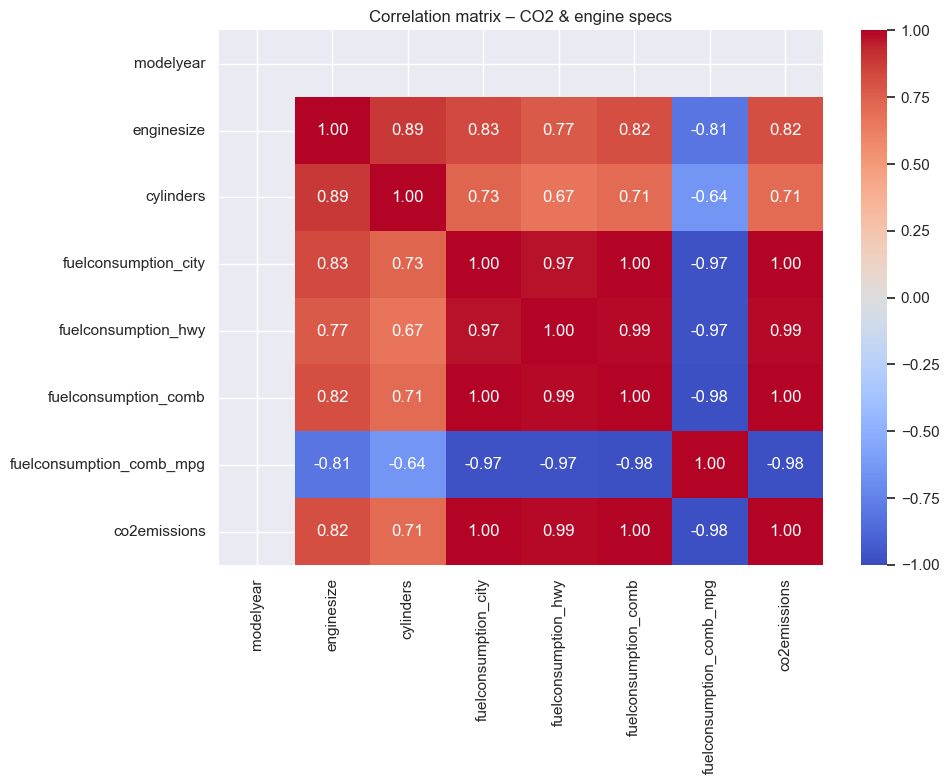

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only numeric columns
numeric_data = merged_df.select_dtypes(include='number')

num_cols = df.select_dtypes(include="number")
corr = num_cols.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix – CO2 & engine specs")
plt.tight_layout()

The correlation heatmap shows the strength and direction of relationships between key engine and fuel consumption features with CO₂ emissions. The values range from -1 to 1, where numbers closer to 1 indicate a strong positive correlation, and numbers closer to -1 indicate a strong negative correlation. In this case, CO₂ emissions have a very strong positive correlation with several features:

1. **fuelconsumption_city** (1.00)<br>
2. **fuelconsumption_hwy** (0.99)<br>
3. **fuelconsumption_comb** (1.00)<br>
4. **enginesize** (0.82)<br>
5. **cylinders** (0.71)

These high values suggest that as engine size, number of cylinders, or fuel consumption increases, CO₂ emissions also increase. In particular, fuel consumption in the city and combined driving conditions are almost perfectly correlated with CO₂ emissions, making them the most critical factors influencing emission levels.

On the other hand, **fuelconsumption_comb_mpg** (miles per gallon) shows a strong negative correlation with CO₂ emissions (-0.98). This means that vehicles with higher fuel efficiency (more miles per gallon) produce significantly lower CO₂ emissions, which is expected. The modelyear has almost no correlation with emissions, indicating that the year alone doesn't strongly determine emission output unless linked with other technical specifications.

In summary, the heatmap reveals that fuel consumption and engine size are the most influential features in determining CO₂ emissions, while higher MPG values are associated with better environmental performance. These results help focus analysis and environmental strategies on improving fuel efficiency and optimizing engine specifications.

#### 2. Engine Size vs CO2 Emissions — *“Bigger engine, more emissions?”*

The scatterplot with a regression line shows the relationship between engine size and CO2 emissions. The graph confirms that vehicles with larger engines tend to produce more CO2 emissions which indicate a strong linear relationship between these two variable. Besides, the uses of this graph also support the clustering feature.

The **plt.figure(figsize=(7, 5))** function sets the size of the output figure to ensure readability. The **sns.regplot()** function from the Seaborn library is used to create both the scatterplot and the fitted regression line. The x and y parameters specify the variables to plot enginesize on the x-axis and co2emissions on the y-axis. The **scatter_kws={'alpha': 0.4}** argument reduces the opacity of the scatter points, making overlapping points easier to see. Labels and a title are added using plt.title(), plt.xlabel(), and plt.ylabel(), while plt.tight_layout() ensures that all elements fit neatly within the display. 

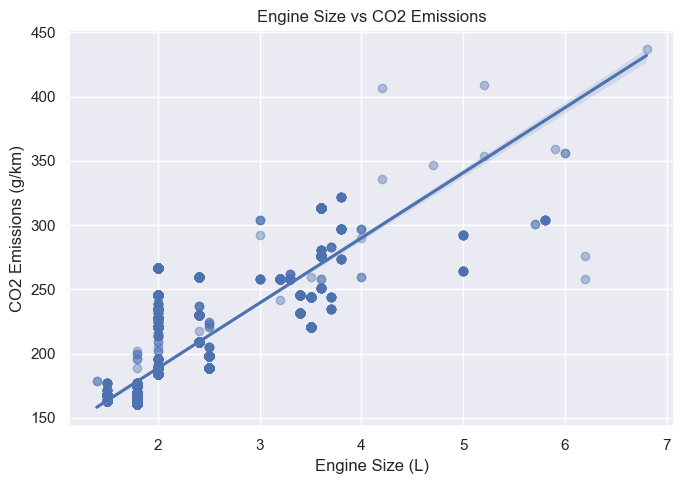

In [287]:
plt.figure(figsize=(7, 5))
sns.regplot(data=merged_df, x='enginesize', y='co2emissions', scatter_kws={'alpha': 0.4})
plt.title("Engine Size vs CO2 Emissions")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.tight_layout()


The scatterplot with a regression line above illustrates the relationship between engine size and CO₂ emissions. From the graph, it is evident that there is a strong positive linear relationship between the two variables. As engine size increases, CO₂ emissions also increase consistently. This means vehicles with larger engines generally release more carbon dioxide per kilometer. The data points closely follow the upward trend of the regression line, which further confirms the strength of the correlation.

Additionally, while most of the data points are concentrated between 1.5L and 4.0L engine sizes, the trend remains consistent even for larger engines. The spread of points around the line is relatively tight, showing low variability and reinforcing that engine size is a strong predictor of emission levels. This visualization supports the conclusion that engine specifications play a significant role in determining a vehicle’s environmental footprint and highlight the importance of this variable for further analysis or policy consideration.

#### 3. CO2 Emissions by Fuel Type — *“Which fuel types pollute more?”*
The boxplot was created using Seaborn and Matplotlib to visualize the distribution of CO₂ emissions across different fuel types. The figure size is set using **plt.figure(figsize=(8, 5))** to ensure the chart is clearly visible and well-proportioned. The core visualization is produced with **sns.boxplot()**, which plots the fuel column on the x-axis and co2emissions on the y-axis. This allows a side-by-side comparison of emission values for each fuel type.

The **boxplot()** function automatically displays key statistical summaries: the box represents the interquartile range (middle 50% of the data), the line inside the box marks the median, and points outside the whiskers are considered outliers. Axis labels and the chart title are added using plt.title(), plt.xlabel(), and plt.ylabel() to ensure the chart is self-explanatory. Finally, plt.tight_layout() is used to adjust spacing and prevent overlap between elements, resulting in a clean and readable layout. This setup enables a clear comparison of CO₂ emission patterns across fuel categories.

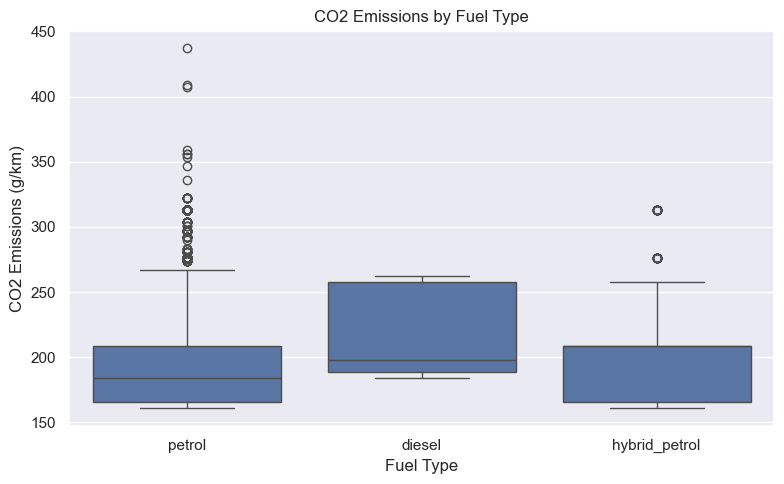

In [289]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x='fuel', y='co2emissions')
plt.title("CO2 Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions (g/km)")
plt.tight_layout()


The boxplot shown below compares the distribution of CO₂ emissions across different fuel types.

**Petrol vehicles:** Show the widest spread of emissions where it contains many high outliers that exceed 350 g/km. This suggests a broader range of engine types and consumption levels. The variation also indicates inconsistency in fuel efficiency among petrol-powered vehicles, likely due to differences in engine capacity, age, and design standards across models.

**Diesel vehicles:** Show a narrower range but slightly higher median CO₂ emissions than petrol, which indicates that it is more consistent even though it emits more on average. This consistency may be due to the standardized nature of diesel engines, but the higher average emissions highlight their environmental drawback, especially in urban or high-usage settings.

**Hybrid petrol vehicles:** Show the lowest median emissions and a more compact range, which supports their reputation as a cleaner alternative. The tight distribution reflects better control of fuel consumption, likely due to the integration of electric components that reduce reliance on the combustion engine during low-speed or idle periods.

Hence, hybrid petrol cars are the most environmentally friendly in terms of CO₂ emissions, while petrol vehicles vary widely, and diesel tends to emit more consistently. These patterns highlight the importance of promoting hybrid and efficient technologies to reduce emissions and improve sustainability in the transport sector.


### 4.0 Conclusion for Phase 2

Phase 2 focused on uncovering insights from the cleaned dataset through descriptive statistics, machine learning, and visual exploration. This stage successfully addressed the research objective of understanding how vehicle characteristics influence CO₂ emissions. Key findings include:

1. **Descriptive Insights:**
Summary statistics revealed that a small number of car makers dominate the dataset, and some of them contribute disproportionately to higher CO₂ emissions. Vehicle class analysis further showed that larger vehicle types, such as SUVs, tend to emit more CO₂ on average.

2. **Correlation Analysis:**
A strong positive correlation was found between fuel consumption and CO₂ emissions, particularly in city and combined driving conditions. Similarly, engine size and cylinders were positively correlated with emissions. Meanwhile, fuel efficiency (MPG) had a strong negative correlation, reinforcing that better fuel economy leads to reduced emissions.

3. **Clustering via K-Means:**
By grouping vehicles into Low, Medium, and High Emission Groups, we gained a clearer segmentation of emission patterns. This clustering helps identify which car models and brands are more environmentally friendly, and which fall into high-emission categories that may need closer scrutiny or improvement.

4. **Visualizations Enhanced Understanding:**
The heatmap confirmed which features matter most in determining emissions while the scatterplot clearly illustrated the linear relationship between engine size and CO₂ emissions. Lastly, the boxplot showed that hybrid vehicles are the most environmentally friendly, diesel vehicles emit consistently more, and petrol vehicles vary widely.

This phase provided a comprehensive analytical foundation for interpreting vehicle emissions and identifying factors that impact environmental performance. The results support data-driven strategies for promoting cleaner and more efficient vehicle technologies.